First visualization of some images from the dataset

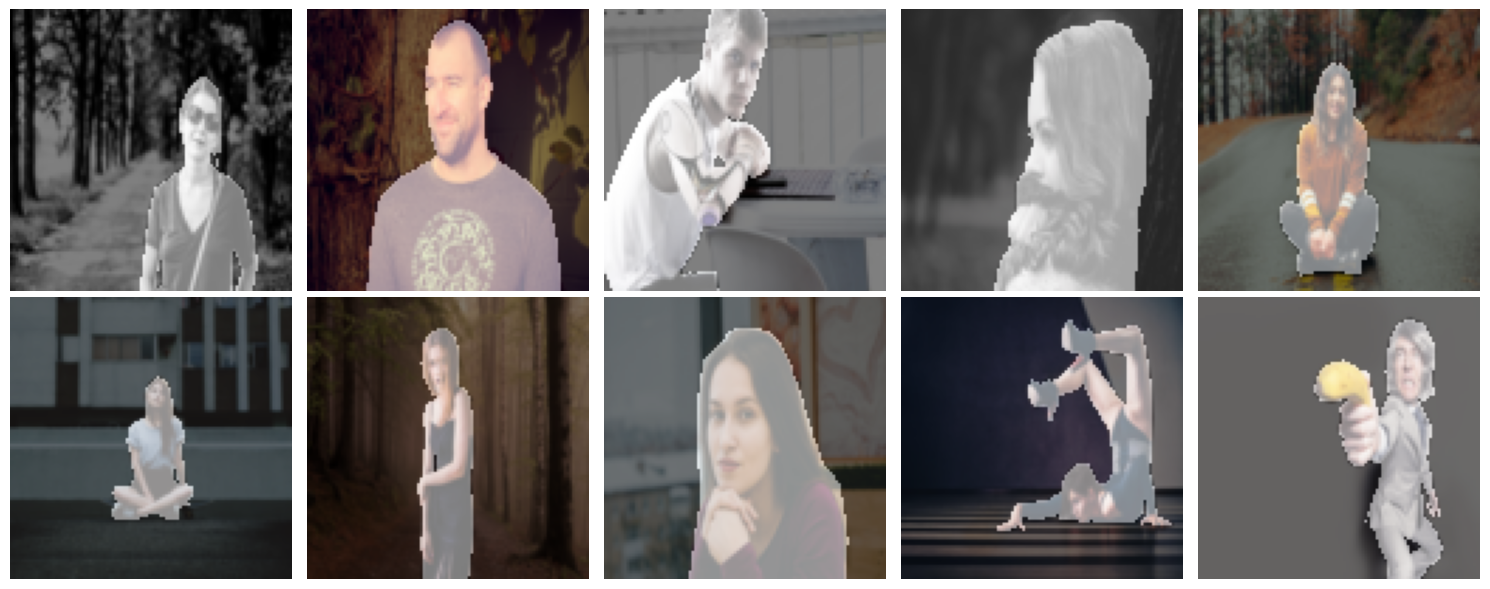

In [25]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import warnings

from skimage import io
from skimage.transform import resize

# Nascondi i warning "is a low contrast image" di skimage
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*is a low contrast image.*"
)

# cartelle input
path_img_in   = "./data/supervisely_person_clean_2667_img/images"
path_mask_in  = "./data/supervisely_person_clean_2667_img/masks"

# cartelle output (100x100)
path_img_out  = "./data/preprocessed/images_100"
path_mask_out = "./data/preprocessed/masks_100"

os.makedirs(path_img_out, exist_ok=True)
os.makedirs(path_mask_out, exist_ok=True)

png_files = [f for f in os.listdir(path_img_in) if f.endswith(".png")]

def resize_and_center_crop_100(img, is_mask=False):
    h, w = img.shape[:2]

    # la dimensione minore diventa 100, l'altra scalata proporzionalmente
    if h < w:
        scale = 100.0 / h
    else:
        scale = 100.0 / w

    new_h = int(round(h * scale))
    new_w = int(round(w * scale))

    order = 0 if is_mask else 1
    anti_aliasing = False if is_mask else True

    img_resized = resize(
        img,
        (new_h, new_w),
        order=order,
        anti_aliasing=anti_aliasing,
        preserve_range=True
    )

    img_resized = img_resized.astype(img.dtype)

    # crop centrale 100x100
    start_y = (new_h - 100) // 2
    start_x = (new_w - 100) // 2
    img_cropped = img_resized[start_y:start_y + 100, start_x:start_x + 100]

    return img_cropped

# 1) PREPROCESSING: ridimensiona TUTTE le immagini e maschere
for name in png_files:
    img_path  = os.path.join(path_img_in, name)
    mask_path = os.path.join(path_mask_in, name)

    img  = io.imread(img_path)   # H x W x C
    mask = io.imread(mask_path)  # H x W (o H x W x C)

    if mask.ndim == 3:
        mask = mask[..., 0]

    img_proc  = resize_and_center_crop_100(img,  is_mask=False)
    mask_proc = resize_and_center_crop_100(mask, is_mask=True)

    # opzionale: binarizza la maschera
    if mask_proc.dtype != np.bool_:
        mask_proc = (mask_proc > 0.5).astype(np.uint8)

    io.imsave(os.path.join(path_img_out, name), img_proc)
    io.imsave(os.path.join(path_mask_out, name), mask_proc)

# 2) VISUALIZZA 10 IMMAGINI CASUALI PREPROCESSATE
all_pre = [f for f in os.listdir(path_img_out) if f.endswith(".png")]
random_images = random.sample(all_pre, min(10, len(all_pre)))  # 10 random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, img_name in enumerate(random_images):
    img_path  = os.path.join(path_img_out, img_name)
    mask_path = os.path.join(path_mask_out, img_name)

    img  = io.imread(img_path)
    mask = io.imread(mask_path)

    axes[idx].imshow(img)
    axes[idx].imshow(mask, alpha=0.5, cmap="gray")
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


todo:
prendi due pixel uno bianco e uno nero di un immagine. crea un immagine quadrata con estremi quei due punti. 
creare le background e image patches.

Poi creeremo un classifier che data una patch, stabilisce a che classe appartiene

In [20]:
import keras
import keras.layers
import tensorflow as tf

def mkmodel():
    input_layer = keras.Input(shape=(None, None, 3), name='input')

    # --- ENCODER ---
    # First block
    x = keras.layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(input_layer)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)# Efficient conv
    # Convoluzione Separabile: Divide il lavoro in due passaggi più semplici:
    # - Depthwise: Analizza solo lo spazio (forme, bordi) canale per canale.
    # - Pointwise (1x1): Mescola i canali (colori, feature) tra loro.

    x = keras.layers.BatchNormalization()(x)
    x1 = x # Save for skip connection
    
    # Downsample
    x = keras.layers.MaxPooling2D(2)(x) 
    # Lavora sull'immagine rimpicciolita. 
    # Cerca forme più complesse (occhi, mani). Usa 64 filtri (più "neuroni" per capire meglio).

    # Instead of 4-8... filters, we start with 32 and go up to 128. 
    # This provides more capacity to learn complex features

    # Second block
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x2 = x # Save for skip connection
    
    # Downsample
    x = keras.layers.MaxPooling2D(2)(x) 

    # Bottleneck - the most abstract features. Qui l'immagine e' molto rimpicciolita
    x = keras.layers.SeparableConv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)

    # --- DECODER ---
    #
    # il modello torna alle dimensioni originali per dipingere la mask.

    # Upsample and Skip Connection 1
    x = keras.layers.UpSampling2D(2)(x)
    x = keras.layers.Concatenate()([x, x2]) # Il modello prende quello che ha capito (dal cervello) e lo unisce alle info dettagliate salvate prima 
    
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu')(x) 
    x = keras.layers.BatchNormalization()(x)

    # Upsample and Skip Connection 2
    x = keras.layers.UpSampling2D(2)(x)
    x = keras.layers.Concatenate()([x, x1])
    
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.SeparableConv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)

    # Output layer
    x = keras.layers.Conv2D(filters=1, kernel_size=(1,1), padding='same', activation='sigmoid')(x)
    
    return keras.Model(input_layer, x)

# Creating the model
model = mkmodel()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Lower LR usually better for deeper nets
              loss=keras.losses.BinaryCrossentropy(from_logits=False), 
              metrics=[keras.metrics.BinaryAccuracy()])

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, None,      │        896 │ input[0][0]       │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_36 │ (None, None,      │      1,344 │ batch_normalizat… │
│ (SeparableConv2D)   │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, None,      │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_37 │ (None, None,      │      2,400 │ max_pooling2d_8[… │
│ (SeparableConv2D)   │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_38 │ (None, None,      │      4,736 │ batch_normalizat… │
│ (SeparableConv2D)   │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, None,      │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_39 │ (None, None,      │      8,896 │ max_pooling2d_9[… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_40 │ (None, None,      │     17,664 │ batch_normalizat… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ separable_conv2d… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, None,      │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, None,      │          0 │ up_sampling2d_8[

 Total params: 62,657 (244.75 KB)

 Trainable params: 61,377 (239.75 KB)

 Non-trainable params: 1,280 (5.00 KB)

Il modello ha una forma a "U": prima rimpicciolisce l'immagine per capirne il contenuto (Encoder), poi la ingrandisce per creare la maschera finale (Decoder).

ENCODER:
Questa parte serve a capire "COSA" c'è nell'immagine ("c'è una persona"), sacrificando il "DOVE" (i dettagli precisi).

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


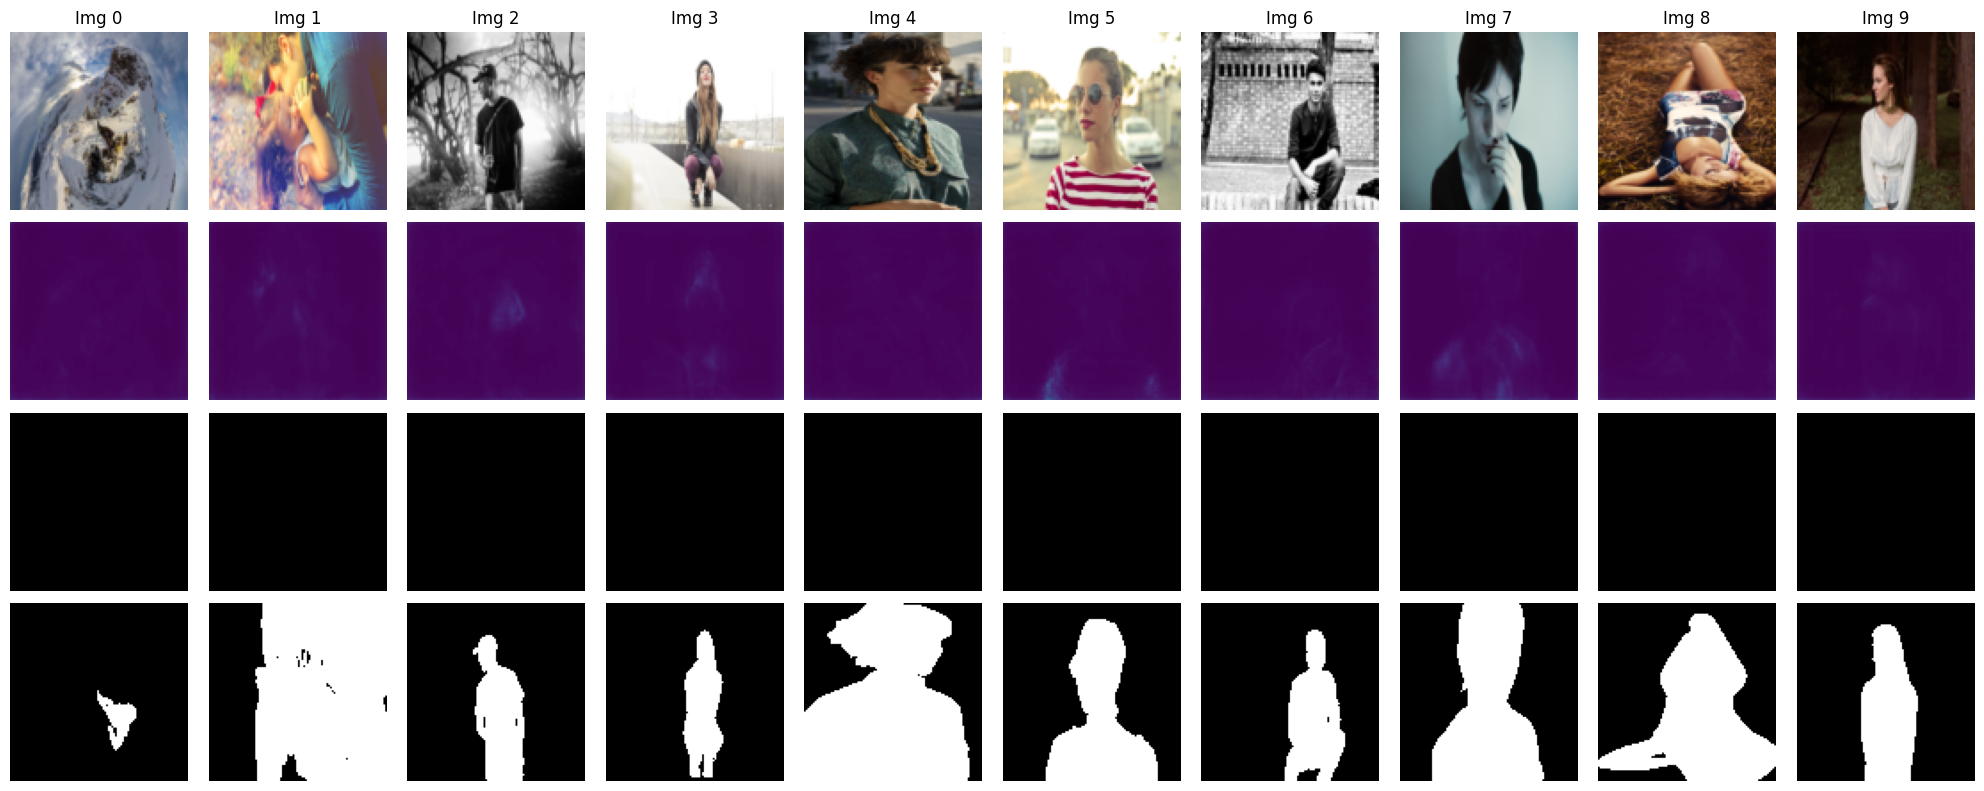

Epoch 1/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - binary_accuracy: 0.8759 - loss: 0.2869 - val_binary_accuracy: 0.6782 - val_loss: 1.1418
Epoch 2/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - binary_accuracy: 0.8753 - loss: 0.2868 - val_binary_accuracy: 0.6999 - val_loss: 0.7894
Epoch 3/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - binary_accuracy: 0.8757 - loss: 0.2866 - val_binary_accuracy: 0.7368 - val_loss: 0.5915
Epoch 4/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - binary_accuracy: 0.8805 - loss: 0.2767 - val_binary_accuracy: 0.7877 - val_loss: 0.4879
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


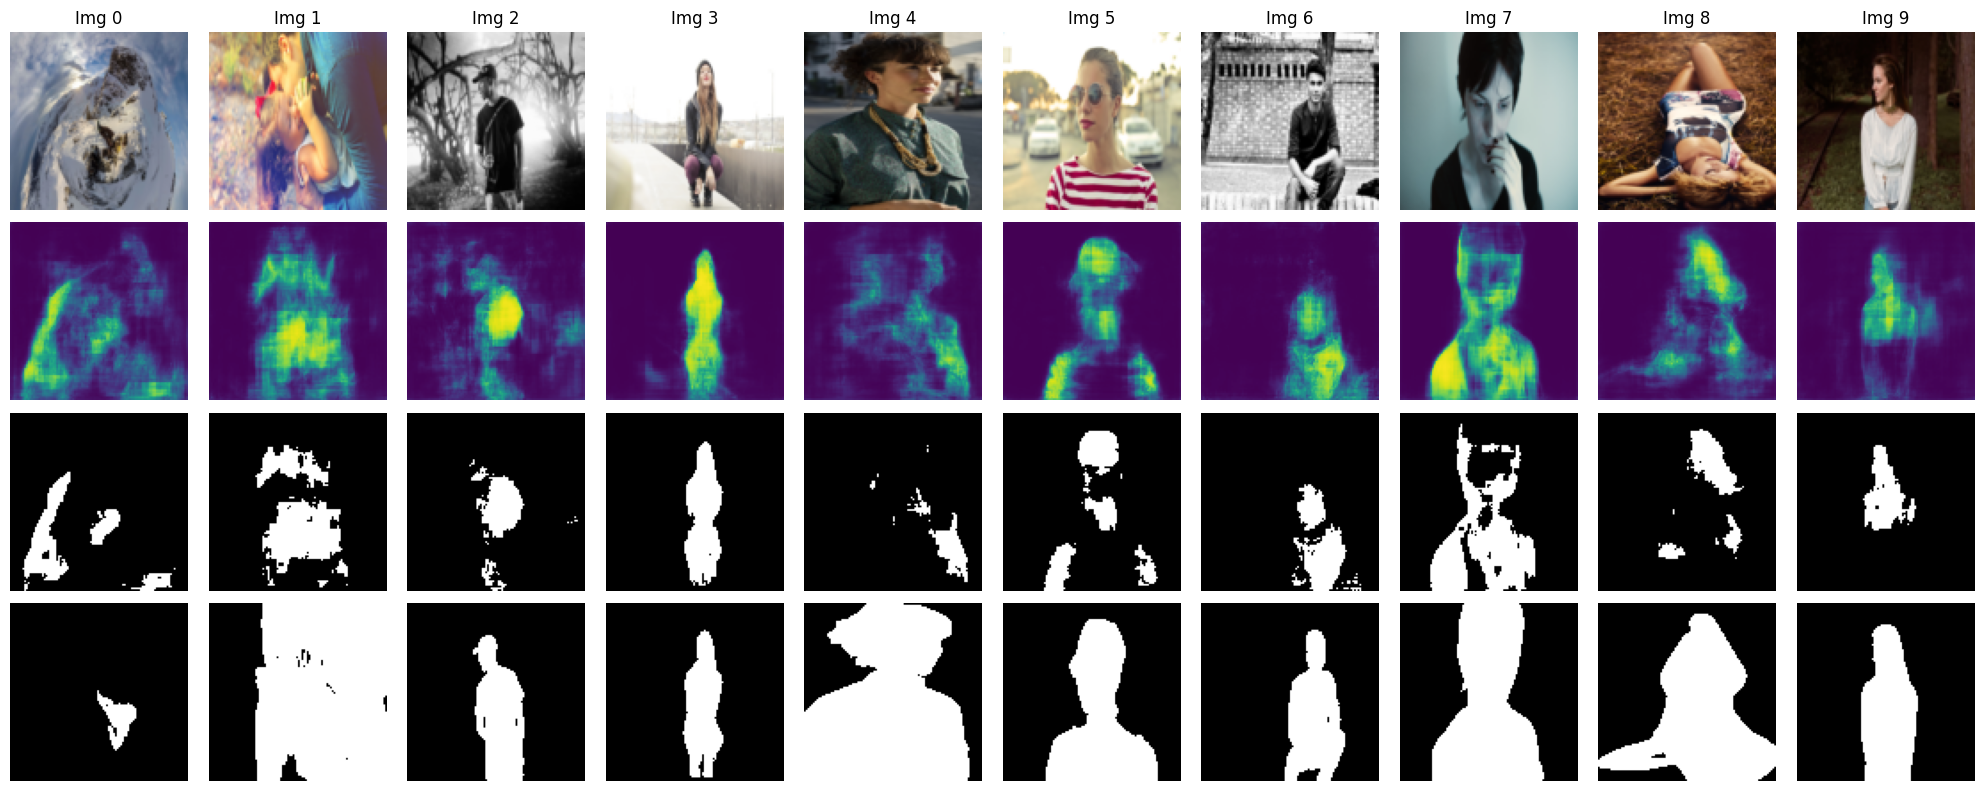

Epoch 1/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - binary_accuracy: 0.8791 - loss: 0.2798 - val_binary_accuracy: 0.8111 - val_loss: 0.4470
Epoch 2/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 34s 979ms/step - binary_accuracy: 0.8856 - loss: 0.2652 - val_binary_accuracy: 0.8568 - val_loss: 0.3373
Epoch 3/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 733ms/step - binary_accuracy: 0.8857 - loss: 0.2644 - val_binary_accuracy: 0.8483 - val_loss: 0.3644
Epoch 4/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 735ms/step - binary_accuracy: 0.8842 - loss: 0.2669 - val_binary_accuracy: 0.8565 - val_loss: 0.3349
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


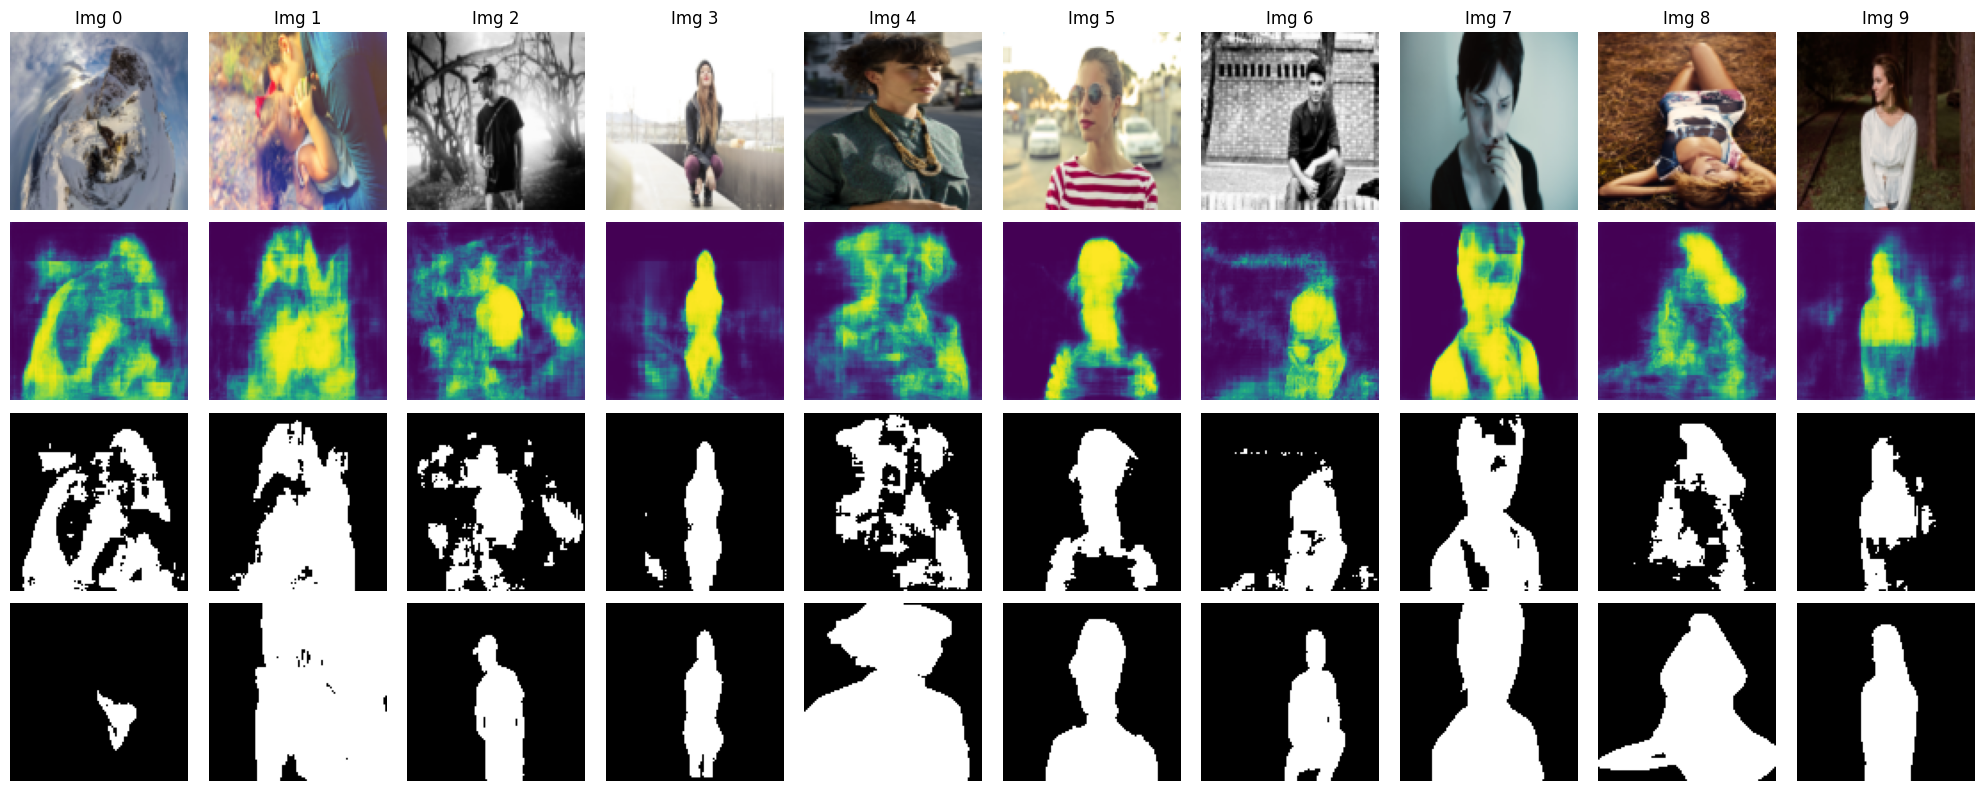

Epoch 1/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 786ms/step - binary_accuracy: 0.8901 - loss: 0.2565 - val_binary_accuracy: 0.8500 - val_loss: 0.3625
Epoch 2/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 735ms/step - binary_accuracy: 0.8915 - loss: 0.2536 - val_binary_accuracy: 0.8624 - val_loss: 0.3291
Epoch 3/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 730ms/step - binary_accuracy: 0.8925 - loss: 0.2511 - val_binary_accuracy: 0.8555 - val_loss: 0.3350
Epoch 4/4
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 739ms/step - binary_accuracy: 0.8954 - loss: 0.2448 - val_binary_accuracy: 0.8631 - val_loss: 0.3162
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


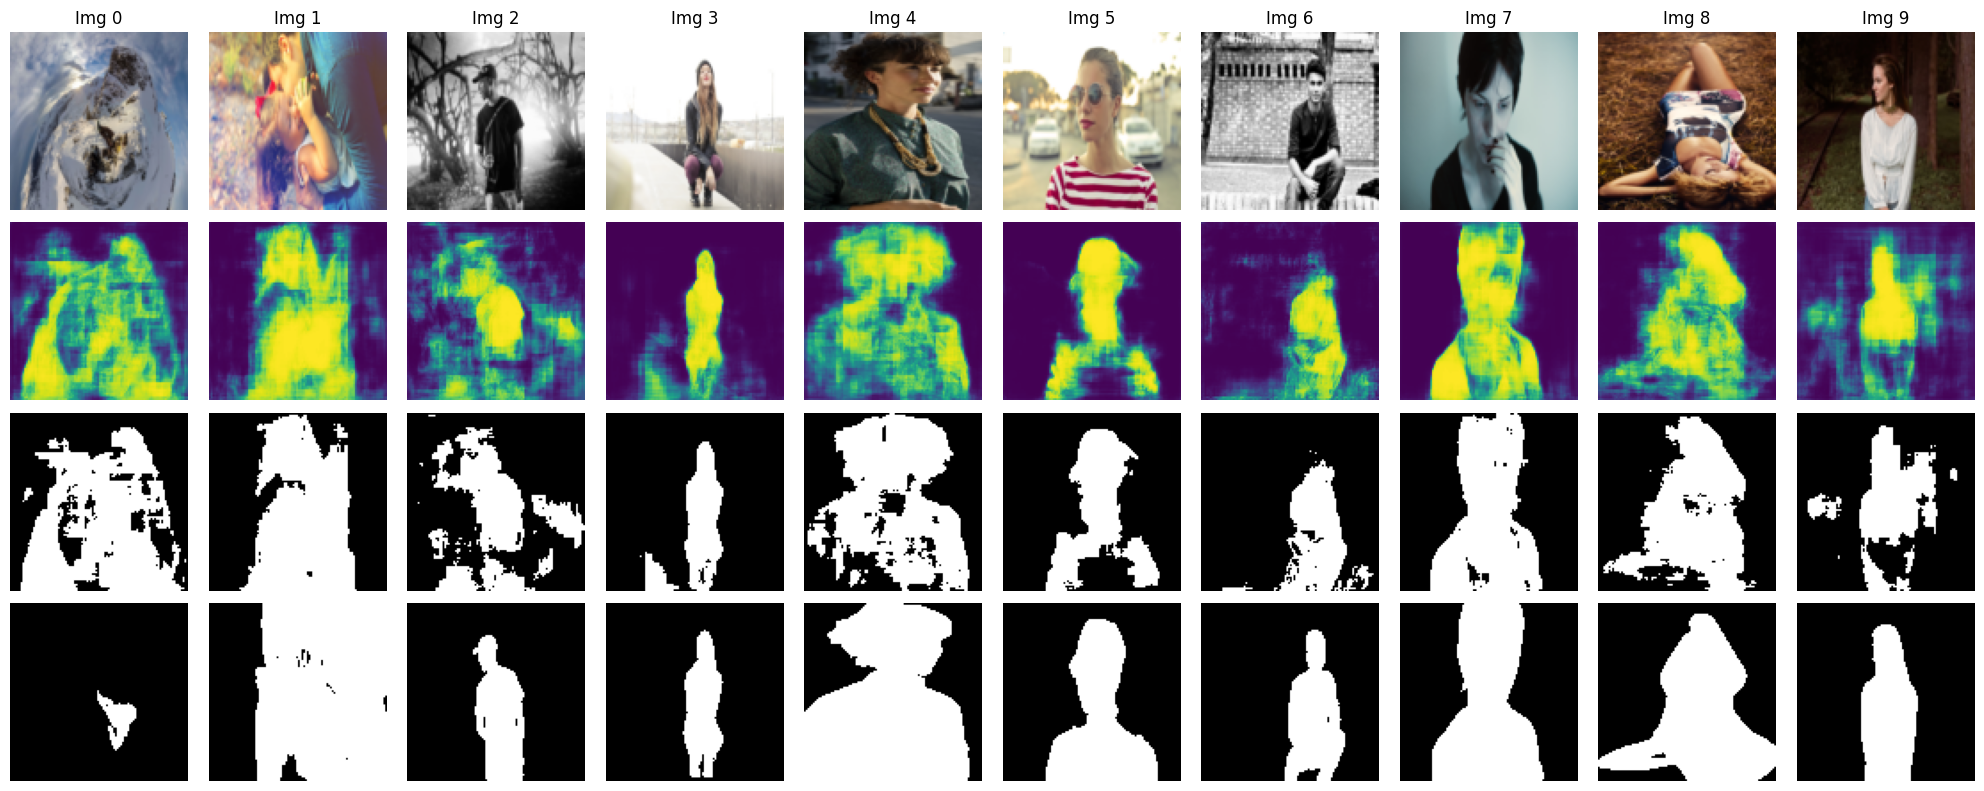

Epoch 1/4
 3/34 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - binary_accuracy: 0.9157 - loss: 0.2045  

KeyboardInterrupt: 

In [ ]:
all_pre = [f for f in os.listdir(path_img_out) if f.endswith(".png")]
all_pre.sort()

X = []
Y = []

for name in all_pre:
    img_path  = os.path.join(path_img_out, name)
    mask_path = os.path.join(path_mask_out, name)

    img  = io.imread(img_path)
    mask = io.imread(mask_path)

    # immagini: forzo sempre 3 canali
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[-1] == 4:
        img = img[..., :3]

    # maschere: forzo shape (H, W, 1)
    if mask.ndim == 3:
        mask = mask[..., 0]
    if mask.ndim == 2:
        mask = np.expand_dims(mask, axis=-1)

    # scarto eventuali outlier
    if img.shape != (100, 100, 3):
        print("skip img:", name, img.shape)
        continue
    if mask.shape != (100, 100, 1):
        print("skip mask:", name, mask.shape)
        continue

    img  = img.astype("float32") / 255.0
    mask = mask.astype("float32")

    X.append(img)
    Y.append(mask)

X = np.stack(X, axis=0)
Y = np.stack(Y, axis=0)

N = X.shape[0]
indices = np.arange(N)
np.random.seed(42)
np.random.shuffle(indices)

split = int(0.8 * N)
train_idx = indices[:split]
test_idx  = indices[split:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_test,  Y_test  = X[test_idx],  Y[test_idx]

import matplotlib.pyplot as plt
import tensorflow as tf

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="./logs")

ntest = 10
tx = X_test[:ntest]
ty = Y_test[:ntest]

while True:
    tyhat = model.predict(tx)

    fig, axs = plt.subplots(nrows=4, ncols=ntest, figsize=(2 * ntest, 8))

    for ti in range(ntest):
        axs[0, ti].imshow(tx[ti])
        axs[0, ti].set_title(f"img {ti}")
        axs[1, ti].imshow(tyhat[ti, :, :, 0], vmin=0, vmax=1, cmap="viridis")
        axs[2, ti].imshow(tyhat[ti, :, :, 0] > 0.5, vmin=0, vmax=1, cmap="gray")
        axs[3, ti].imshow(ty[ti, :, :, 0], vmin=0, vmax=1, cmap="gray")

    for ax in axs.flatten():
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    model.fit(
        X_train,
        Y_train,
        validation_data=(X_test, Y_test),
        epochs=4,
        batch_size=64,
        callbacks=[tensorboard_callback],
        shuffle=True,
    )
